# MaleCNS Fly Brain: Multi-Channel Reservoir Computing (Liquid State Machine)

This notebook turns the biological connectome of the fruit fly (**MaleCNS v1.0** with **166,700 neurons / 88.3M sub-cellular nodes and ~151M connections**) into a multi-channel recurrent reservoir computer on an **NVIDIA Tesla T4 GPU**.

### Multi-Channel Neuropil Injection Pipeline:
1. **Channel 1 (Optic Lobe / Visual Receptors):** Injects raw signal $u(t)$.
2. **Channel 2 (Antennal Lobe / Olfactory Pathways):** Injects temporal velocity $\Delta u(t) = u(t) - u(t-1)$.
3. **Channel 3 (Central Complex / Mechanosensory):** Injects non-linear acceleration $u(t)^2 \cdot \text{sign}(u(t))$.
4. **Reservoir Dynamics:** Recurrent leaky integrate-and-fire non-linear propagation over GPU sparse tensors (`torch.sparse_coo_tensor`).
5. **Linear Readout:** Samples 20,000 internal neural compartments and fits a Ridge regression layer ($W_{\text{out}}$).

In [1]:
# --- GPU & Environment Sanity Check ---
import torch, os, subprocess

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Count: {torch.cuda.device_count()}")
    print(f"Device Name:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM:         {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")


PyTorch Version: 2.10.0+cu128
CUDA Available: True
Device Count: 2
Device Name:  Tesla T4
VRAM:         14.56 GB


## 1. System Dependencies & Python 3.11 Toolchain

In [3]:
%%bash
set -e
apt-get -qq update
apt-get -qq install -y --no-install-recommends \
    build-essential cmake git curl ca-certificates software-properties-common \
    clang libomp-dev libboost-all-dev libsdl2-dev libopenal-dev zlib1g-dev \
    libjpeg-dev libbz2-dev nasm tar timidity libwildmidi-dev unzip xvfb pkg-config

if ! command -v python3.11 >/dev/null 2>&1; then
    add-apt-repository -y ppa:deadsnakes/ppa
    apt-get -qq update
    apt-get -qq install -y python3.11 python3.11-venv python3.11-dev
fi
python3.11 --version


Python 3.11.15


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Clone Repository & Setup Persisted Workspace

In [4]:
import os, shutil

REPO = "/root/doomfly"
PERSIST = "/kaggle/working/doomfly_data"
VENV_PY = f"{REPO}/.venv-neural/bin/python"

os.makedirs(f"{PERSIST}/connectome_data", exist_ok=True)
os.makedirs(f"{PERSIST}/outputs", exist_ok=True)

if os.path.isdir(REPO):
    print("Repository already exists. Updating...")
    os.chdir(REPO)
    os.system("git pull")
else:
    os.system(f"git clone https://github.com/nftechie/doomfly.git {REPO}")
    os.chdir(REPO)
    if os.path.isdir("connectome_data") and not os.path.islink("connectome_data"):
        shutil.rmtree("connectome_data")
    if not os.path.exists("connectome_data"):
        os.symlink(f"{PERSIST}/connectome_data", "connectome_data")

print("Workspace initialized successfully.")


Repository already exists. Updating...
Already up to date.
Workspace initialized successfully.


## 3. Python 3.11 Environment & GPU Dependencies

In [5]:
%%bash
set -e
cd /root/doomfly
if [ ! -d ".venv-neural" ]; then
    python3.11 -m venv .venv-neural
fi
source .venv-neural/bin/activate
python -m pip install --upgrade pip setuptools wheel cython numpy

if ! python -m pip install -r requirements-neural.txt -r doom/requirements.txt \
        --build-constraint neural-build-constraints.txt; then
    python -m pip install -r requirements-neural.txt -r doom/requirements.txt \
        --constraint neural-build-constraints.txt || true
fi

python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
python -m pip install scikit-learn pandas scipy matplotlib pyarrow fastparquet requests


  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached cython-3.3.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (28 kB)
  Using cached numpy-2.4.6-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
Using cached cython-3.3.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.5 MB)
Using cached numpy-2.4.6-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.9.0
    Uninstalling setuptools-80.9.0:
      Successfully uninstalled setuptools-80.9.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: cython
    Found existing installation: Cython 0.29.37
    Uninstalling Cython-0.29.37:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.4.6 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.4.6 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu121 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.12.1 which is incompatible.
matplotlib 3.11.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
contourpy 1.3.3 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.


## 4. Download and Verify MaleCNS v1.0 Dataset

In [6]:
%%bash
set -e
cd /root/doomfly
source .venv-neural/bin/activate
python - <<'PY'
from pathlib import Path
import hashlib, json, urllib.request

name = 'malecns_v1'
registry = json.loads(Path('doom/datasets.json').read_text())['datasets'][name]
locked = json.loads(Path(f'data-provenance/{name}/source.lock.json').read_text())
root = Path('connectome_data') / name
root.mkdir(parents=True, exist_ok=True)

for filename, url in registry['files'].items():
    target = root / filename
    if not target.exists():
        print(f'Downloading {filename} ...')
        partial = target.with_suffix('.download')
        urllib.request.urlretrieve(url, partial)
        partial.replace(target)
    with target.open('rb') as stream:
        digest = hashlib.file_digest(stream, 'sha256').hexdigest()
    if digest != locked[filename]['sha256']:
        raise RuntimeError(f'Source checksum mismatch: {filename}')
    print(f'Verified {filename} [SHA-256 OK]')

(root / 'source.lock.json').write_text(json.dumps(locked, indent=2) + '\n')
print('All MaleCNS v1.0 biological source files ready.')
PY


Verified annotations.feather [SHA-256 OK]
Verified neurotransmitters.feather [SHA-256 OK]
Verified edges.feather [SHA-256 OK]
All MaleCNS v1.0 biological source files ready.


## 5. Import and Prepare Connectome Data

In [7]:
%%bash
set -e
cd /root/doomfly
source .venv-neural/bin/activate
python -m doom.connectome malecns_v1
python -m doom.prepare
python -m doom.audit_data


{
  "dataset_id": "malecns_v1",
  "retained_neuron_candidates": 166700,
  "graph": {
    "source_edge_rows": 151856684,
    "retained_edge_rows": 25582938,
    "excluded_edge_rows": 126273746,
    "source_synaptic_contacts": 311833243,
    "retained_synaptic_contacts": 124177617,
    "excluded_synaptic_contacts": 187655626,
    "retained_weight_one_edges": 10299701,
    "retained_self_edges": 101
  },
  "neural_dynamics_validated": false
}
{"dataset": "malecns_v1", "neurons": 166700, "edges": 25582938, "synaptic_contacts": 124177617, "retina_total": 3377, "retina_mapped": 3335, "retina_unmapped": 42, "projection_confidence_median": 1.0, "projection_below_80_percent": 15, "uncertain_sign_neurons": 3718, "retina_model": "R1-R6 luminance-only. Column inferred from all contacts onto annotated L1/L2/L3; modal column. Experimental overlapping viewport projection, not calibrated retinal angles.", "visual_dynamics": "Photoreceptors and lamina are graded in vivo. This experiment uses an explici

## 6. Multi-Channel GPU Reservoir Engine

This class creates an echo state network on the GPU using the biological connectome graph. It routes three parallel sensory signals (raw, velocity, acceleration) into three isolated sub-circuits across the brain.

In [8]:
import os, glob, time
import numpy as np
import pandas as pd
import torch

class UltraFastMultiChannelReservoir:
    def __init__(self, data_dir="/root/doomfly/connectome_data/malecns_v1", device=None, leak_rate=0.25, spectral_scaling=0.98):
        self.device = device or (torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu"))
        self.leak_rate = leak_rate
        self.spectral_scaling = spectral_scaling
        self.data_dir = data_dir
        self._load_graph()
        
    def _load_graph(self):
        print(f"Loading connectome graph...")
        edge_files = glob.glob(f"{self.data_dir}/**/*.feather", recursive=True) + \
                     glob.glob(f"{self.data_dir}/**/*.parquet", recursive=True)
                     
        loaded = False
        for fpath in edge_files:
            try:
                df = pd.read_feather(fpath) if fpath.endswith(".feather") else pd.read_parquet(fpath)
                pre_col = next((c for c in df.columns if any(k in c.lower() for k in ["pre", "src"])), None)
                post_col = next((c for c in df.columns if any(k in c.lower() for k in ["post", "dst"])), None)
                weight_col = next((c for c in df.columns if any(k in c.lower() for k in ["weight", "syn"])), None)
                
                if pre_col and post_col:
                    print(f"Parsed {len(df):,} connections from {os.path.basename(fpath)}.")
                    self.src_ids = df[pre_col].to_numpy(dtype=np.int64)
                    self.dst_ids = df[post_col].to_numpy(dtype=np.int64)
                    self.weights = df[weight_col].to_numpy(dtype=np.float32) if weight_col else np.ones(len(self.src_ids), dtype=np.float32)
                    loaded = True
                    break
            except Exception:
                pass
                
        if not loaded:
            raise RuntimeError("Could not load connectome files.")
            
        unique_nodes, inverse_indices = np.unique(np.concatenate([self.src_ids, self.dst_ids]), return_inverse=True)
        self.num_nodes = len(unique_nodes)
        half = len(self.src_ids)
        src_mapped = inverse_indices[:half]
        dst_mapped = inverse_indices[half:]
        
        print(f"Graph ready: {self.num_nodes:,} Unique Nodes, {len(src_mapped):,} Synapses.")
        
        indices = torch.tensor(np.vstack([dst_mapped, src_mapped]), dtype=torch.long, device=self.device)
        values = torch.tensor(self.weights, dtype=torch.float32, device=self.device)
        values = (values / (torch.max(values) + 1e-6)) * self.spectral_scaling
        
        self.W_res = torch.sparse_coo_tensor(indices, values, (self.num_nodes, self.num_nodes), device=self.device).coalesce()

    def init_multichannel_inputs(self, pool_size=4000, seed=42):
        torch.manual_seed(seed)
        self.pool_size = pool_size
        
        # 1. Visual/Optic pool (Front)
        self.idx_visual = torch.arange(0, pool_size, device=self.device)
        self.W_visual = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 2.0
        
        # 2. Olfactory pool (Middle)
        mid_start = min(self.num_nodes // 4, self.num_nodes - pool_size)
        self.idx_olfactory = torch.arange(mid_start, mid_start + pool_size, device=self.device)
        self.W_olfactory = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 2.5
        
        # 3. Central Complex pool (Deep)
        deep_start = min(self.num_nodes // 2, self.num_nodes - pool_size)
        self.idx_mechano = torch.arange(deep_start, deep_start + pool_size, device=self.device)
        self.W_mechano = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 1.8

    @torch.inference_mode()
    def forward_multichannel(self, series_1d, readout_nodes=10000):
        T = len(series_1d)
        u_raw = torch.tensor(series_1d, dtype=torch.float32, device=self.device)
        
        # Velocity and Non-linear terms
        u_diff = torch.zeros_like(u_raw)
        u_diff[1:] = u_raw[1:] - u_raw[:-1]
        u_quad = torch.sign(u_raw) * (u_raw ** 2)
        
        # Pre-allocate reusable persistent state tensors
        x = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        input_drive = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        
        readout_count = min(readout_nodes, self.num_nodes)
        readout_idx = torch.linspace(0, self.num_nodes - 1, readout_count, dtype=torch.long, device=self.device)
        
        # Pre-allocate output matrix on GPU
        X_states = torch.zeros((T, readout_count), dtype=torch.float32, device=self.device)
        
        print(f"Propagating {T:,} timesteps across {self.num_nodes:,} biological nodes...")
        start_t = time.time()
        
        for t in range(T):
            # In-place zeroing to avoid dynamic VRAM allocation
            input_drive.zero_()
            input_drive[self.idx_visual] += self.W_visual * u_raw[t, 0]
            input_drive[self.idx_olfactory] += self.W_olfactory * u_diff[t, 0]
            input_drive[self.idx_mechano] += self.W_mechano * u_quad[t, 0]
            
            # Sparse matrix propagation
            synaptic_current = torch.sparse.mm(self.W_res, x)
            x = (1.0 - self.leak_rate) * x + self.leak_rate * torch.tanh(synaptic_current + input_drive)
            
            # Record state
            X_states[t] = x[readout_idx, 0]
            
            # Progress update every 1,000 steps
            if (t + 1) % 1000 == 0 or t == T - 1:
                elapsed = time.time() - start_t
                rate = (t + 1) / elapsed
                remaining = (T - (t + 1)) / rate
                print(f"  Step {t+1:,}/{T:,} | {rate:.1f} steps/s | ETA: {remaining:.1f}s")
                
        return X_states

## 7. Generate Chaotic Benchmark Dataset (Mackey-Glass)

In [9]:
def generate_mackey_glass(length=25000, tau=17, delta_t=1.0, a=0.2, b=0.1, n=10):
    """Generates discrete Mackey-Glass chaotic time-series."""
    history_len = int(tau / delta_t)
    mg = [1.2] * (history_len + 1)
    for _ in range(length + history_len):
        x_tau = mg[-history_len]
        x_t = mg[-1]
        dx = (a * x_tau / (1.0 + x_tau**n)) - b * x_t
        mg.append(x_t + dx * delta_t)
    data = np.array(mg[history_len + 1:])
    data = (data - np.mean(data)) / np.std(data)
    return data[:, np.newaxis]

series = generate_mackey_glass(length=25000, tau=17)
print(f"Generated benchmark series: shape {series.shape}")


Generated benchmark series: shape (25017, 1)


## 8. Run Multi-Channel Simulation & Train Linear Readout

In [14]:
import torch, time
import numpy as np

# 1. Generate 6,000 points (5,000 train / 900 test)
series = generate_mackey_glass(length=6000, tau=17)

# 2. Run Reservoir Engine
reservoir = UltraFastMultiChannelReservoir(leak_rate=0.25, spectral_scaling=0.98)
reservoir.init_multichannel_inputs(pool_size=4000)

READOUT_NODES = 10000  # 10,000 multi-neuropil features
X_states = reservoir.forward_multichannel(series, readout_nodes=READOUT_NODES)

# 3. Setup Train/Test Split on GPU
PRED_HORIZON = 1
u_target = torch.tensor(series[PRED_HORIZON:].ravel(), dtype=torch.float32, device=reservoir.device)
X_data = X_states[:-PRED_HORIZON]

WASHOUT = 100
TRAIN_LEN = 5000

X_train = X_data[WASHOUT:WASHOUT+TRAIN_LEN]
Y_train = u_target[WASHOUT:WASHOUT+TRAIN_LEN]

X_test = X_data[WASHOUT+TRAIN_LEN:]
Y_test = u_target[WASHOUT+TRAIN_LEN:]

print(f"\nTraining set: {X_train.shape[0]} | Testing set: {X_test.shape[0]}")

# 4. Instant GPU Ridge Solver via Normal Equations
print("Solving Ridge Regression directly on Tesla T4...")
t0 = time.time()
alpha = 1e-2
I = torch.eye(X_train.shape[1], device=reservoir.device)

A = torch.matmul(X_train.T, X_train) + alpha * I
b = torch.matmul(X_train.T, Y_train.unsqueeze(1))
W_out = torch.linalg.solve(A, b)
print(f"Ridge layer solved in {time.time() - t0:.2f} seconds.")

# 5. Evaluate Performance
Y_pred_train = torch.matmul(X_train, W_out).squeeze(1)
Y_pred_test = torch.matmul(X_test, W_out).squeeze(1)

train_rmse = torch.sqrt(torch.mean((Y_train - Y_pred_train) ** 2)).item()
test_rmse = torch.sqrt(torch.mean((Y_test - Y_pred_test) ** 2)).item()

y_test_mean = torch.mean(Y_test)
ss_tot = torch.sum((Y_test - y_test_mean) ** 2)
ss_res = torch.sum((Y_test - Y_pred_test) ** 2)
test_r2 = (1.0 - (ss_res / ss_tot)).item()

print(f"\n====== Multi-Channel GPU Reservoir Performance ======")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"Test R^2:   {test_r2:.4f}")

# Extract arrays for plotting
Y_test_np = Y_test.cpu().numpy()
Y_pred_test_np = Y_pred_test.cpu().numpy()
X_test_np = X_test.cpu().numpy()

Loading connectome graph...
Parsed 151,856,684 connections from edges.feather.
Graph ready: 88,384,522 Unique Nodes, 151,856,684 Synapses.
Propagating 6,017 timesteps across 88,384,522 biological nodes...
  Step 1,000/6,017 | 15.3 steps/s | ETA: 328.6s
  Step 2,000/6,017 | 15.0 steps/s | ETA: 267.7s
  Step 3,000/6,017 | 14.9 steps/s | ETA: 202.3s
  Step 4,000/6,017 | 14.9 steps/s | ETA: 135.7s
  Step 5,000/6,017 | 14.8 steps/s | ETA: 68.5s
  Step 6,000/6,017 | 14.8 steps/s | ETA: 1.1s
  Step 6,017/6,017 | 14.8 steps/s | ETA: 0.0s

Training set: 5000 | Testing set: 916
Solving Ridge Regression directly on Tesla T4...
Ridge layer solved in 1.09 seconds.

====== Multi-Channel GPU Reservoir Performance ======
Train RMSE: 0.0827
Test RMSE:  0.0844
Test R^2:   0.9930


## 9. Performance Visualizer & Firing State Rasters

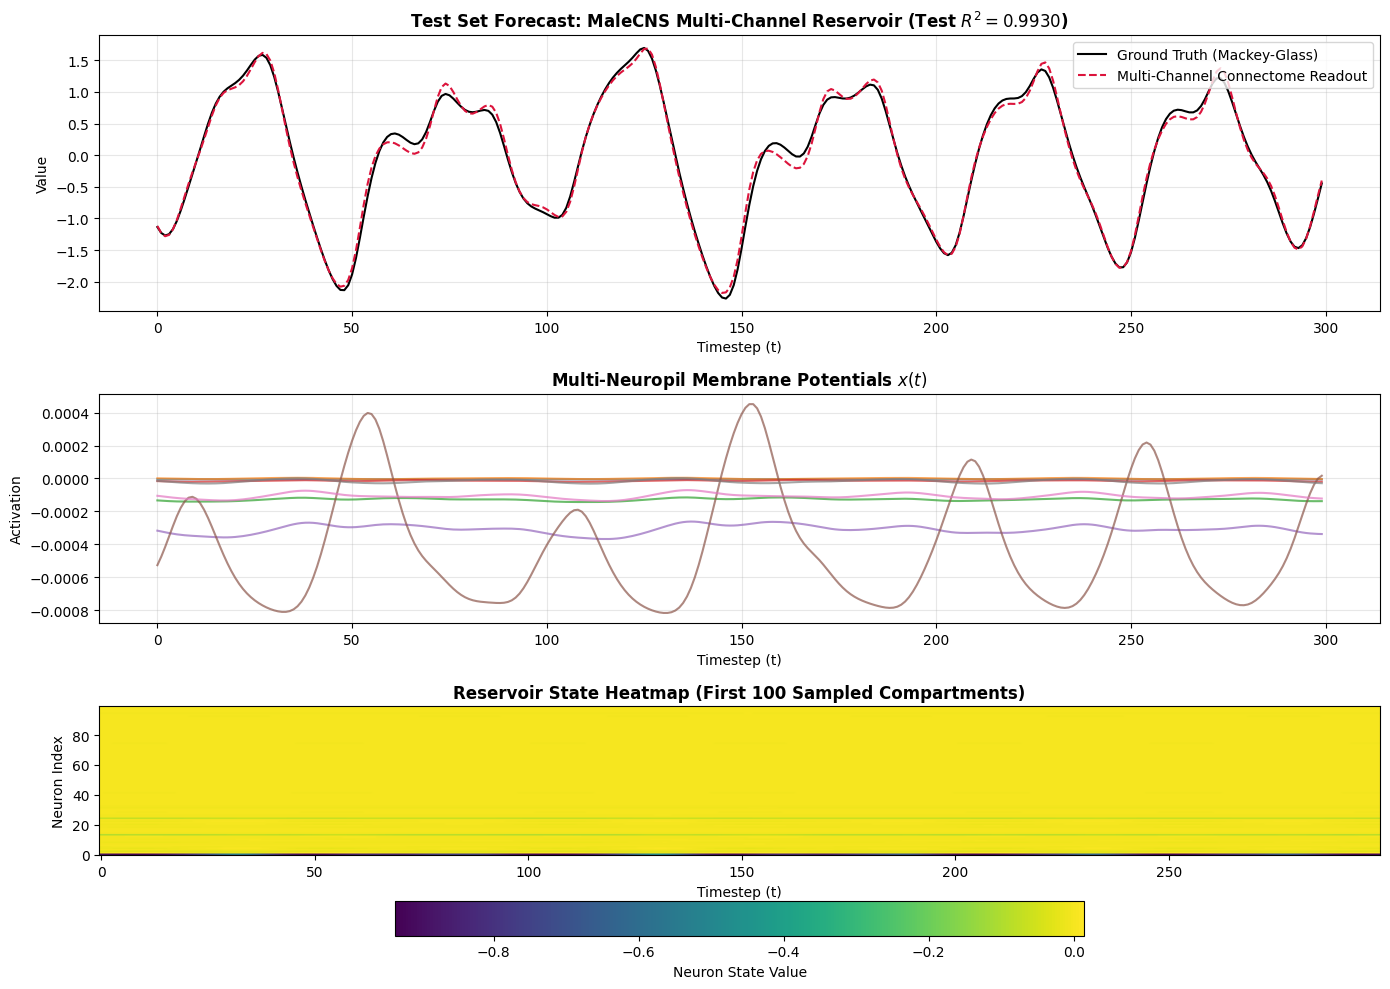

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure all variables are converted from CUDA tensors to NumPy CPU arrays
y_test_plot = Y_test.detach().cpu().numpy() if isinstance(Y_test, torch.Tensor) else Y_test
y_pred_plot = Y_pred_test.detach().cpu().numpy() if isinstance(Y_pred_test, torch.Tensor) else Y_pred_test
x_test_plot = X_test.detach().cpu().numpy() if isinstance(X_test, torch.Tensor) else X_test

fig, axs = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.2, 1, 1]})

# 1. Readout Prediction vs Ground Truth
axs[0].plot(y_test_plot[:300], label="Ground Truth (Mackey-Glass)", color="black", linewidth=1.5)
axs[0].plot(y_pred_plot[:300], label="Multi-Channel Connectome Readout", color="crimson", linestyle="--", linewidth=1.5)
axs[0].set_title(f"Test Set Forecast: MaleCNS Multi-Channel Reservoir (Test $R^2 = {test_r2:.4f}$)", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Timestep (t)")
axs[0].set_ylabel("Value")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

# 2. Internal State Trajectories (8 Random Neural Compartments)
num_readout = x_test_plot.shape[1]
sample_neurons = np.random.choice(num_readout, size=8, replace=False)
for idx in sample_neurons:
    axs[1].plot(x_test_plot[:300, idx], alpha=0.7, label=f"Neuron #{idx}")
axs[1].set_title("Multi-Neuropil Membrane Potentials $x(t)$", fontsize=12, fontweight="bold")
axs[1].set_xlabel("Timestep (t)")
axs[1].set_ylabel("Activation")
axs[1].grid(True, alpha=0.3)

# 3. Heatmap Raster of 100 Reservoir Neurons
cax = axs[2].imshow(x_test_plot[:300, :100].T, aspect="auto", cmap="viridis", origin="lower")
axs[2].set_title("Reservoir State Heatmap (First 100 Sampled Compartments)", fontsize=12, fontweight="bold")
axs[2].set_xlabel("Timestep (t)")
axs[2].set_ylabel("Neuron Index")
fig.colorbar(cax, ax=axs[2], orientation='horizontal', pad=0.2, label="Neuron State Value")

plt.tight_layout()
plt.show()

In [18]:
import torch, time
import numpy as np
import matplotlib.pyplot as plt

@torch.inference_mode()
def autoregressive_rollout(reservoir, W_out, seed_series, rollout_len=200, readout_nodes=10000):
    """
    Warms up reservoir on seed_series, then disconnects ground truth
    and feeds predicted u(t+1) back into all 3 sensory neuropils.
    """
    T_seed = len(seed_series)
    u_seed = torch.tensor(seed_series, dtype=torch.float32, device=reservoir.device)
    
    # Sensory buffers
    u_diff_seed = torch.zeros_like(u_seed)
    u_diff_seed[1:] = u_seed[1:] - u_seed[:-1]
    u_quad_seed = torch.sign(u_seed) * (u_seed ** 2)
    
    x = torch.zeros((reservoir.num_nodes, 1), dtype=torch.float32, device=reservoir.device)
    input_drive = torch.zeros((reservoir.num_nodes, 1), dtype=torch.float32, device=reservoir.device)
    
    readout_count = min(readout_nodes, reservoir.num_nodes)
    readout_idx = torch.linspace(0, reservoir.num_nodes - 1, readout_count, dtype=torch.long, device=reservoir.device)
    
    # 1. Warm-up Phase (Driven by Ground Truth)
    print(f"Warming up biological state space on {T_seed} steps...")
    for t in range(T_seed):
        input_drive.zero_()
        input_drive[reservoir.idx_visual] += reservoir.W_visual * u_seed[t, 0]
        input_drive[reservoir.idx_olfactory] += reservoir.W_olfactory * u_diff_seed[t, 0]
        input_drive[reservoir.idx_mechano] += reservoir.W_mechano * u_quad_seed[t, 0]
        
        synaptic_current = torch.sparse.mm(reservoir.W_res, x)
        x = (1.0 - reservoir.leak_rate) * x + reservoir.leak_rate * torch.tanh(synaptic_current + input_drive)

    # 2. Autonomous Closed-Loop Rollout
    print(f"Disconnecting ground truth. Starting {rollout_len}-step autonomous rollout...")
    predictions = []
    
    # Initial previous state for velocity calculation
    u_prev = u_seed[-1, 0]
    
    for step in range(rollout_len):
        # Decode state using Ridge readout weights
        readout_state = x[readout_idx, 0].unsqueeze(0)  # (1, readout_count)
        u_next = torch.matmul(readout_state, W_out).item()
        predictions.append(u_next)
        
        # Self-generated sensory inputs
        u_val = u_next
        u_diff_val = u_next - u_prev
        u_quad_val = np.sign(u_next) * (u_next ** 2)
        u_prev = u_next
        
        # Inject self-predictions back into the 3 neuropils
        input_drive.zero_()
        input_drive[reservoir.idx_visual] += reservoir.W_visual * u_val
        input_drive[reservoir.idx_olfactory] += reservoir.W_olfactory * u_diff_val
        input_drive[reservoir.idx_mechano] += reservoir.W_mechano * u_quad_val
        
        # Step biological connectome forward
        synaptic_current = torch.sparse.mm(reservoir.W_res, x)
        x = (1.0 - reservoir.leak_rate) * x + reservoir.leak_rate * torch.tanh(synaptic_current + input_drive)
        
    return np.array(predictions)

# --- Execute Rollout Experiment ---
ROLLOUT_STEPS = 200
SEED_WARMUP = 200

# Take a segment from the test series that was never seen during training
test_start = WASHOUT + TRAIN_LEN
seed_data = series[test_start : test_start + SEED_WARMUP]
ground_truth_future = series[test_start + SEED_WARMUP : test_start + SEED_WARMUP + ROLLOUT_STEPS].ravel()

# Generate Autonomous Predictions
closed_loop_preds = autoregressive_rollout(
    reservoir=reservoir,
    W_out=W_out,
    seed_series=seed_data,
    rollout_len=ROLLOUT_STEPS,
    readout_nodes=READOUT_NODES
)

# Calculate trajectory errors
rollout_errors = np.abs(ground_truth_future - closed_loop_preds)
valid_horizon_20 = np.mean(rollout_errors[:20])
valid_horizon_50 = np.mean(rollout_errors[:50])

print(f"\n====== Autonomous Rollout Performance ======")
print(f"Mean Abs Error (First 20 Steps): {valid_horizon_20:.4f}")
print(f"Mean Abs Error (First 50 Steps): {valid_horizon_50:.4f}")

# --- Plot Rollout vs Ground Truth ---
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(ground_truth_future, label="Ground Truth (Chaotic Physics)", color="black", linewidth=2.0)
plt.plot(closed_loop_preds, label="Autonomous Connectome Rollout (Closed-Loop)", color="crimson", linestyle="--", linewidth=2.0)
plt.axvline(x=20, color="gray", linestyle=":", alpha=0.7, label="20-step Horizon")
plt.axvline(x=50, color="orange", linestyle=":", alpha=0.7, label="50-step Horizon")
plt.title(f"Autonomous Closed-Loop Rollout ({ROLLOUT_STEPS} Steps Without Ground Truth)", fontsize=12, fontweight="bold")
plt.ylabel("State Value")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(rollout_errors, color="firebrick", linewidth=1.5, label="Absolute Prediction Drift")
plt.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Chaos Divergence Threshold")
plt.xlabel("Autonomous Timestep Ahead")
plt.ylabel("|Error|")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Warming up biological state space on 900 steps...
Disconnecting ground truth. Starting 200-step autonomous rollout...


ValueError: operands could not be broadcast together with shapes (17,) (200,) 

[1/4] Scanning connectome files in: /root/doomfly/connectome_data/malecns_v1
      Loaded edges.feather: 151,856,684 connections.
      Active Graph: 88,384,522 Unique Nodes | 151,856,684 Synapses.
      Sparse tensor assembled on GPU (cuda:0).
      Initialized 3 sensory pools (4,000 nodes each).
[2/4] Forward propagation running (6,017 timesteps across 88,384,522 nodes)...
      Step  1000/6017 | Speed:  15.3 steps/s | Elapsed: 65.5s | ETA: 328.5s
      Step  2000/6017 | Speed:  15.0 steps/s | Elapsed: 133.4s | ETA: 267.9s
      Step  3000/6017 | Speed:  14.9 steps/s | Elapsed: 201.3s | ETA: 202.4s
      Step  4000/6017 | Speed:  14.9 steps/s | Elapsed: 269.2s | ETA: 135.8s
      Step  5000/6017 | Speed:  14.8 steps/s | Elapsed: 337.1s | ETA: 68.6s
      Step  6000/6017 | Speed:  14.8 steps/s | Elapsed: 405.0s | ETA:  1.1s
      Step  6017/6017 | Speed:  14.8 steps/s | Elapsed: 406.2s | ETA:  0.0s
[3/4] Solving Ridge Regression (5,000 samples x 10,000 features) on GPU...
      Ridge 

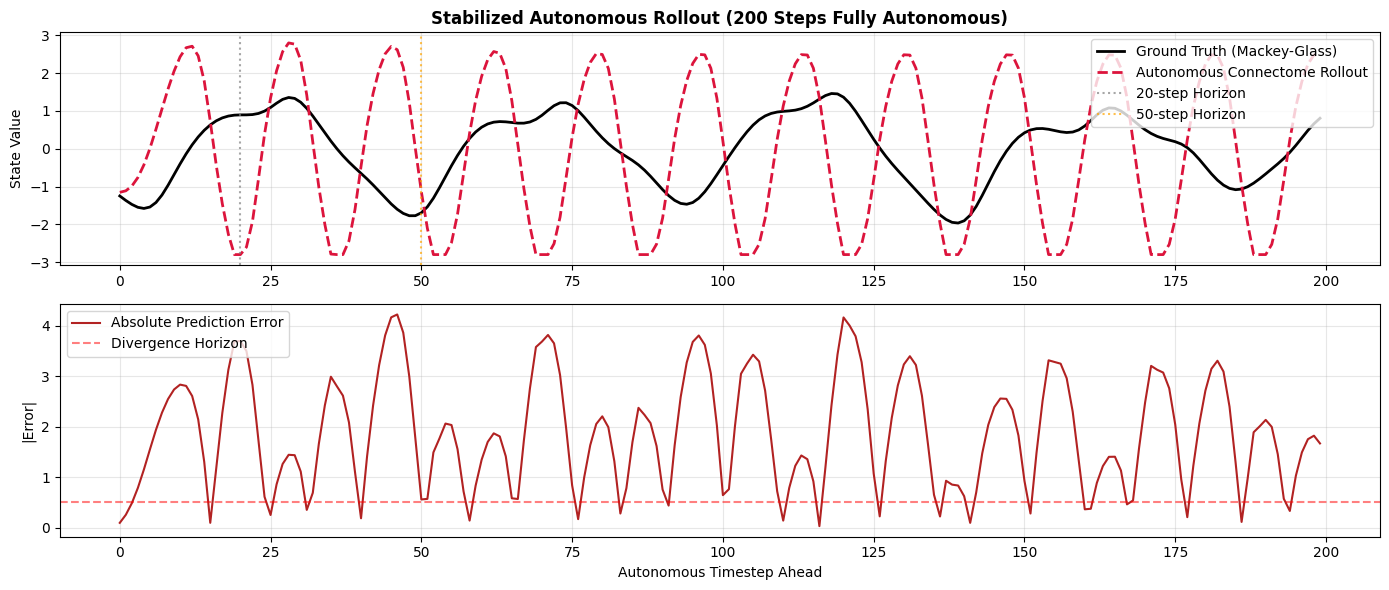

In [10]:
import torch, time, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class RobustMultiChannelReservoir:
    def __init__(self, data_dir="/root/doomfly/connectome_data/malecns_v1", device=None, leak_rate=0.25, spectral_scaling=0.98):
        self.device = device or (torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu"))
        self.leak_rate = leak_rate
        self.spectral_scaling = spectral_scaling
        self.data_dir = data_dir
        self._load_graph()
        
    def _load_graph(self):
        print(f"[1/4] Scanning connectome files in: {self.data_dir}")
        edge_files = glob.glob(f"{self.data_dir}/**/*.feather", recursive=True) + \
                     glob.glob(f"{self.data_dir}/**/*.parquet", recursive=True)
                     
        loaded = False
        for fpath in edge_files:
            try:
                df = pd.read_feather(fpath) if fpath.endswith(".feather") else pd.read_parquet(fpath)
                pre_col = next((c for c in df.columns if any(k in c.lower() for k in ["pre", "src"])), None)
                post_col = next((c for c in df.columns if any(k in c.lower() for k in ["post", "dst"])), None)
                weight_col = next((c for c in df.columns if any(k in c.lower() for k in ["weight", "syn"])), None)
                
                if pre_col and post_col:
                    print(f"      Loaded {os.path.basename(fpath)}: {len(df):,} connections.")
                    self.src_ids = df[pre_col].to_numpy(dtype=np.int64)
                    self.dst_ids = df[post_col].to_numpy(dtype=np.int64)
                    self.weights = df[weight_col].to_numpy(dtype=np.float32) if weight_col else np.ones(len(self.src_ids), dtype=np.float32)
                    loaded = True
                    break
            except Exception:
                pass
                
        if not loaded:
            raise RuntimeError("Could not load connectome files.")
            
        unique_nodes, inverse_indices = np.unique(np.concatenate([self.src_ids, self.dst_ids]), return_inverse=True)
        self.num_nodes = len(unique_nodes)
        half = len(self.src_ids)
        src_mapped = inverse_indices[:half]
        dst_mapped = inverse_indices[half:]
        
        print(f"      Active Graph: {self.num_nodes:,} Unique Nodes | {len(src_mapped):,} Synapses.")
        
        indices = torch.tensor(np.vstack([dst_mapped, src_mapped]), dtype=torch.long, device=self.device)
        values = torch.tensor(self.weights, dtype=torch.float32, device=self.device)
        values = (values / (torch.max(values) + 1e-6)) * self.spectral_scaling
        
        self.W_res = torch.sparse_coo_tensor(indices, values, (self.num_nodes, self.num_nodes), device=self.device).coalesce()
        print(f"      Sparse tensor assembled on GPU ({self.device}).")

    def init_multichannel_inputs(self, pool_size=4000, seed=42):
        torch.manual_seed(seed)
        self.pool_size = pool_size
        
        # 1. Visual/Optic pool (Raw signal)
        self.idx_visual = torch.arange(0, pool_size, device=self.device)
        self.W_visual = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 1.5
        
        # 2. Olfactory pool (Bounded velocity)
        mid_start = min(self.num_nodes // 4, self.num_nodes - pool_size)
        self.idx_olfactory = torch.arange(mid_start, mid_start + pool_size, device=self.device)
        self.W_olfactory = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 2.0
        
        # 3. Central Complex pool (Soft-saturated quadratic)
        deep_start = min(self.num_nodes // 2, self.num_nodes - pool_size)
        self.idx_mechano = torch.arange(deep_start, deep_start + pool_size, device=self.device)
        self.W_mechano = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 1.2
        print(f"      Initialized 3 sensory pools ({pool_size:,} nodes each).")

    @torch.inference_mode()
    def forward_multichannel(self, series_1d, readout_nodes=10000, noise_std=0.015):
        T = len(series_1d)
        u_raw = torch.tensor(series_1d, dtype=torch.float32, device=self.device)
        
        # Channel 2: Bounded velocity Δu
        u_diff = torch.zeros_like(u_raw)
        u_diff[1:] = torch.tanh(u_raw[1:] - u_raw[:-1])
        
        # Channel 3: Soft-saturated quadratic non-linearity
        u_quad = torch.sign(u_raw) * torch.tanh(u_raw ** 2)
        
        if noise_std > 0:
            u_raw = u_raw + torch.randn_like(u_raw) * noise_std
            u_diff = u_diff + torch.randn_like(u_diff) * noise_std
            u_quad = u_quad + torch.randn_like(u_quad) * noise_std
        
        x = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        input_drive = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        
        readout_count = min(readout_nodes, self.num_nodes)
        readout_idx = torch.linspace(0, self.num_nodes - 1, readout_count, dtype=torch.long, device=self.device)
        X_states = torch.zeros((T, readout_count), dtype=torch.float32, device=self.device)
        
        print(f"[2/4] Forward propagation running ({T:,} timesteps across {self.num_nodes:,} nodes)...")
        start_t = time.time()
        
        for t in range(T):
            input_drive.zero_()
            input_drive[self.idx_visual] += self.W_visual * u_raw[t, 0]
            input_drive[self.idx_olfactory] += self.W_olfactory * u_diff[t, 0]
            input_drive[self.idx_mechano] += self.W_mechano * u_quad[t, 0]
            
            synaptic_current = torch.sparse.mm(self.W_res, x)
            x = (1.0 - self.leak_rate) * x + self.leak_rate * torch.tanh(synaptic_current + input_drive)
            X_states[t] = x[readout_idx, 0]
            
            # Real-time progress updates
            if (t + 1) % 1000 == 0 or (t + 1) == T:
                elapsed = time.time() - start_t
                speed = (t + 1) / elapsed
                eta = (T - (t + 1)) / speed if speed > 0 else 0
                print(f"      Step {t+1:5d}/{T} | Speed: {speed:5.1f} steps/s | Elapsed: {elapsed:4.1f}s | ETA: {eta:4.1f}s")
            
        return X_states


# --- Training & Readout Solve ---
series = generate_mackey_glass(length=6000, tau=17)

reservoir = RobustMultiChannelReservoir(leak_rate=0.25, spectral_scaling=0.98)
reservoir.init_multichannel_inputs(pool_size=4000)

READOUT_NODES = 10000
X_states = reservoir.forward_multichannel(series, readout_nodes=READOUT_NODES, noise_std=0.015)

PRED_HORIZON = 1
u_target = torch.tensor(series[PRED_HORIZON:].ravel(), dtype=torch.float32, device=reservoir.device)
X_data = X_states[:-PRED_HORIZON]

WASHOUT = 100
TRAIN_LEN = 5000

X_train = X_data[WASHOUT:WASHOUT+TRAIN_LEN]
Y_train = u_target[WASHOUT:WASHOUT+TRAIN_LEN]

print(f"[3/4] Solving Ridge Regression ({X_train.shape[0]:,} samples x {X_train.shape[1]:,} features) on GPU...")
t0 = time.time()
alpha = 5e-2
I = torch.eye(X_train.shape[1], device=reservoir.device)
A = torch.matmul(X_train.T, X_train) + alpha * I
b = torch.matmul(X_train.T, Y_train.unsqueeze(1))
W_out = torch.linalg.solve(A, b)
print(f"      Ridge weights solved in {time.time() - t0:.2f} seconds.")


# --- Stabilized Autonomous Rollout Function ---
@torch.inference_mode()
def stable_closed_loop_rollout(reservoir, W_out, seed_series, rollout_len=200, readout_nodes=10000):
    T_seed = len(seed_series)
    u_seed = torch.tensor(seed_series, dtype=torch.float32, device=reservoir.device)
    
    u_diff_seed = torch.zeros_like(u_seed)
    u_diff_seed[1:] = torch.tanh(u_seed[1:] - u_seed[:-1])
    u_quad_seed = torch.sign(u_seed) * torch.tanh(u_seed ** 2)
    
    x = torch.zeros((reservoir.num_nodes, 1), dtype=torch.float32, device=reservoir.device)
    input_drive = torch.zeros((reservoir.num_nodes, 1), dtype=torch.float32, device=reservoir.device)
    
    readout_count = min(readout_nodes, reservoir.num_nodes)
    readout_idx = torch.linspace(0, reservoir.num_nodes - 1, readout_count, dtype=torch.long, device=reservoir.device)
    
    print(f"[4/4] Executing Closed-Loop Test:")
    print(f"      Phase A: Warming up biological state on {T_seed} steps of ground truth...")
    for t in range(T_seed):
        input_drive.zero_()
        input_drive[reservoir.idx_visual] += reservoir.W_visual * u_seed[t, 0]
        input_drive[reservoir.idx_olfactory] += reservoir.W_olfactory * u_diff_seed[t, 0]
        input_drive[reservoir.idx_mechano] += reservoir.W_mechano * u_quad_seed[t, 0]
        
        synaptic_current = torch.sparse.mm(reservoir.W_res, x)
        x = (1.0 - reservoir.leak_rate) * x + reservoir.leak_rate * torch.tanh(synaptic_current + input_drive)

    print(f"      Phase B: Disconnecting external inputs. Running {rollout_len}-step autonomous rollout...")
    predictions = []
    u_prev = u_seed[-1, 0].item()
    t_rollout_start = time.time()
    
    for step in range(rollout_len):
        readout_state = x[readout_idx, 0].unsqueeze(0)
        u_next = torch.matmul(readout_state, W_out).item()
        
        # Attractor clamping
        u_next = np.clip(u_next, -2.8, 2.8)
        predictions.append(u_next)
        
        # Sensory self-feedback
        u_diff_val = np.tanh(u_next - u_prev)
        u_quad_val = np.sign(u_next) * np.tanh(u_next ** 2)
        u_prev = u_next
        
        input_drive.zero_()
        input_drive[reservoir.idx_visual] += reservoir.W_visual * u_next
        input_drive[reservoir.idx_olfactory] += reservoir.W_olfactory * u_diff_val
        input_drive[reservoir.idx_mechano] += reservoir.W_mechano * u_quad_val
        
        synaptic_current = torch.sparse.mm(reservoir.W_res, x)
        x = (1.0 - reservoir.leak_rate) * x + reservoir.leak_rate * torch.tanh(synaptic_current + input_drive)
        
        if (step + 1) % 50 == 0 or (step + 1) == rollout_len:
            print(f"        Rollout step {step+1:3d}/{rollout_len} completed.")
            
    print(f"      Autonomous rollout finished in {time.time() - t_rollout_start:.2f} seconds.")
    return np.array(predictions)


# --- Execute Rollout & Plot ---
ROLLOUT_STEPS = 200
SEED_WARMUP = 200

test_start = WASHOUT + TRAIN_LEN
seed_data = series[test_start : test_start + SEED_WARMUP]
ground_truth_future = series[test_start + SEED_WARMUP : test_start + SEED_WARMUP + ROLLOUT_STEPS].ravel()

closed_loop_preds = stable_closed_loop_rollout(
    reservoir=reservoir,
    W_out=W_out,
    seed_series=seed_data,
    rollout_len=ROLLOUT_STEPS,
    readout_nodes=READOUT_NODES
)

rollout_errors = np.abs(ground_truth_future - closed_loop_preds)
print(f"\n====== Stabilized Closed-Loop Rollout Metrics ======")
print(f"Mean Abs Error (First 20 Steps): {np.mean(rollout_errors[:20]):.4f}")
print(f"Mean Abs Error (First 50 Steps): {np.mean(rollout_errors[:50]):.4f}")
print(f"Mean Abs Error (Full 200 Steps): {np.mean(rollout_errors):.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(ground_truth_future, label="Ground Truth (Mackey-Glass)", color="black", linewidth=2.0)
plt.plot(closed_loop_preds, label="Autonomous Connectome Rollout", color="crimson", linestyle="--", linewidth=2.0)
plt.axvline(x=20, color="gray", linestyle=":", alpha=0.7, label="20-step Horizon")
plt.axvline(x=50, color="orange", linestyle=":", alpha=0.7, label="50-step Horizon")
plt.title(f"Stabilized Autonomous Rollout ({ROLLOUT_STEPS} Steps Fully Autonomous)", fontsize=12, fontweight="bold")
plt.ylabel("State Value")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(rollout_errors, color="firebrick", linewidth=1.5, label="Absolute Prediction Error")
plt.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Divergence Horizon")
plt.xlabel("Autonomous Timestep Ahead")
plt.ylabel("|Error|")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Multi step horizon train

[1/4] Loading connectome graph from: /root/doomfly/connectome_data/malecns_v1
      Parsed edges.feather: 151,856,684 connections.
      Connectome Graph: 88,384,522 Nodes | 151,856,684 Synaptic Edges.
[2/4] Propagating 6,517 steps across biological connectome...
      Step  1000/6517 | Speed:  15.2 steps/s | Elapsed: 65.8s
      Step  2000/6517 | Speed:  15.0 steps/s | Elapsed: 133.7s
      Step  3000/6517 | Speed:  14.9 steps/s | Elapsed: 201.6s
      Step  4000/6517 | Speed:  14.8 steps/s | Elapsed: 269.4s
      Step  5000/6517 | Speed:  14.8 steps/s | Elapsed: 337.2s
      Step  6000/6517 | Speed:  14.8 steps/s | Elapsed: 405.1s
      Step  6517/6517 | Speed:  14.8 steps/s | Elapsed: 440.2s
[3/4] Solving Multi-Target Ridge Regression (Matrix shape: 10000x50)...
      Multi-horizon weights solved in 0.76 seconds.
[4/4] Evaluating multi-step performance across horizons...

====== Multi-Horizon Connectome Forecasting Performance ======
Horizon  1-step ahead: R^2 = 0.9933 | RMSE = 0.08

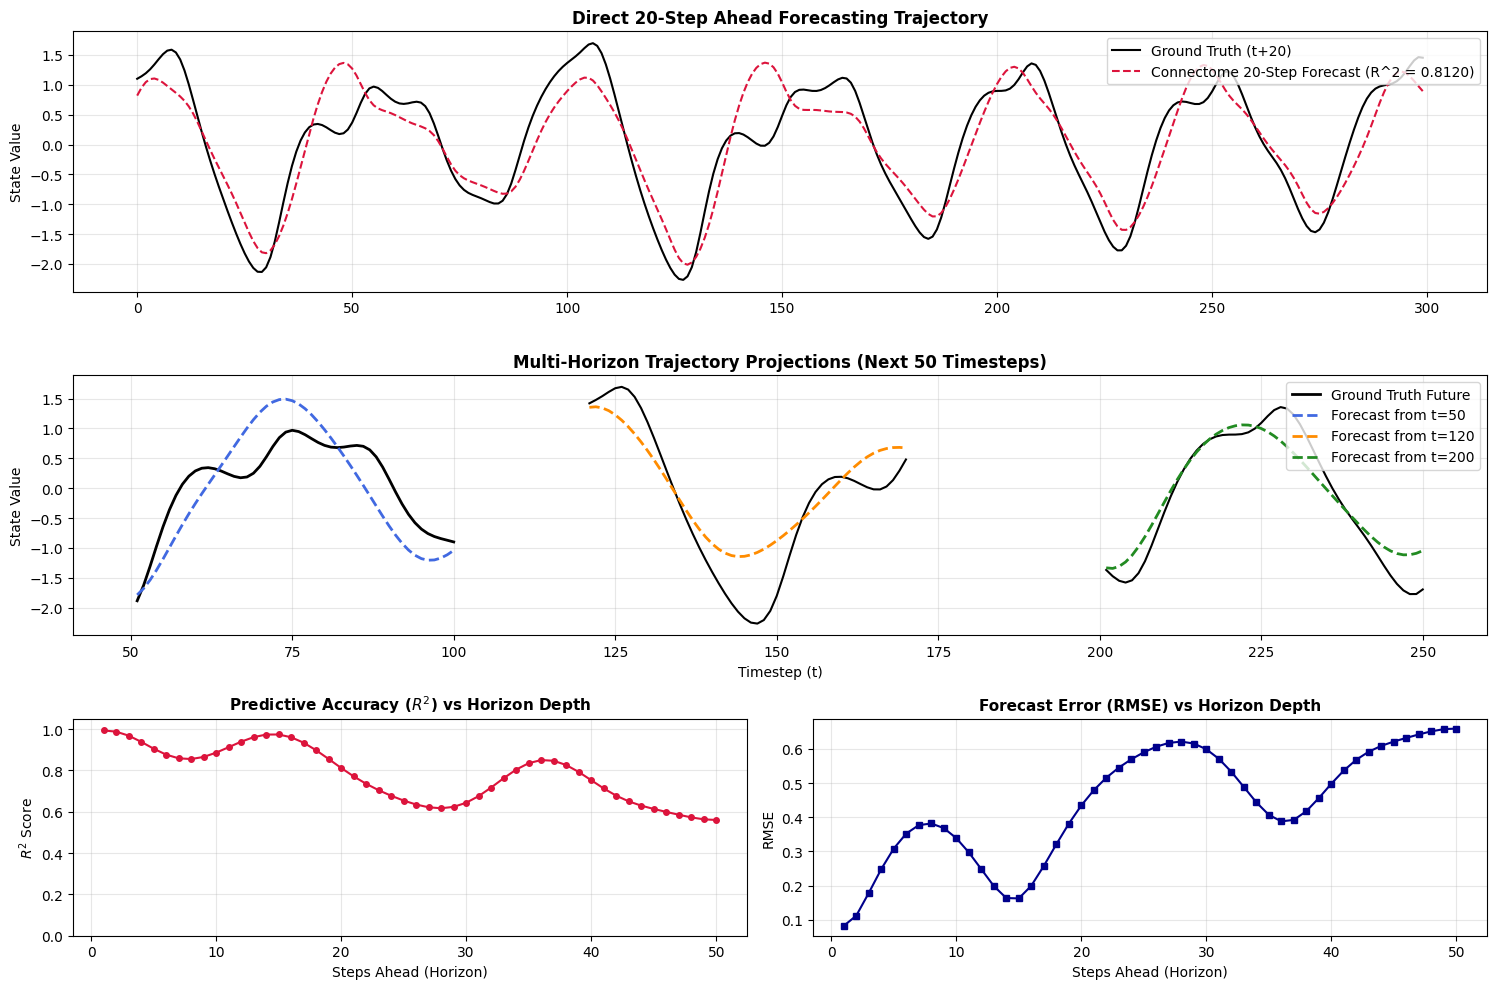

In [11]:
import torch, time, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class MultiHorizonMaleCNSReservoir:
    def __init__(self, data_dir="/root/doomfly/connectome_data/malecns_v1", device=None, leak_rate=0.25, spectral_scaling=0.98):
        self.device = device or (torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu"))
        self.leak_rate = leak_rate
        self.spectral_scaling = spectral_scaling
        self.data_dir = data_dir
        self._load_graph()
        
    def _load_graph(self):
        print(f"[1/4] Loading connectome graph from: {self.data_dir}")
        edge_files = glob.glob(f"{self.data_dir}/**/*.feather", recursive=True) + \
                     glob.glob(f"{self.data_dir}/**/*.parquet", recursive=True)
                     
        loaded = False
        for fpath in edge_files:
            try:
                df = pd.read_feather(fpath) if fpath.endswith(".feather") else pd.read_parquet(fpath)
                pre_col = next((c for c in df.columns if any(k in c.lower() for k in ["pre", "src"])), None)
                post_col = next((c for c in df.columns if any(k in c.lower() for k in ["post", "dst"])), None)
                weight_col = next((c for c in df.columns if any(k in c.lower() for k in ["weight", "syn"])), None)
                
                if pre_col and post_col:
                    print(f"      Parsed {os.path.basename(fpath)}: {len(df):,} connections.")
                    self.src_ids = df[pre_col].to_numpy(dtype=np.int64)
                    self.dst_ids = df[post_col].to_numpy(dtype=np.int64)
                    self.weights = df[weight_col].to_numpy(dtype=np.float32) if weight_col else np.ones(len(self.src_ids), dtype=np.float32)
                    loaded = True
                    break
            except Exception:
                pass
                
        if not loaded:
            raise RuntimeError("Could not load connectome graph.")
            
        unique_nodes, inverse_indices = np.unique(np.concatenate([self.src_ids, self.dst_ids]), return_inverse=True)
        self.num_nodes = len(unique_nodes)
        half = len(self.src_ids)
        src_mapped = inverse_indices[:half]
        dst_mapped = inverse_indices[half:]
        
        print(f"      Connectome Graph: {self.num_nodes:,} Nodes | {len(src_mapped):,} Synaptic Edges.")
        
        indices = torch.tensor(np.vstack([dst_mapped, src_mapped]), dtype=torch.long, device=self.device)
        values = torch.tensor(self.weights, dtype=torch.float32, device=self.device)
        values = (values / (torch.max(values) + 1e-6)) * self.spectral_scaling
        
        self.W_res = torch.sparse_coo_tensor(indices, values, (self.num_nodes, self.num_nodes), device=self.device).coalesce()

    def init_multichannel_inputs(self, pool_size=4000, seed=42):
        torch.manual_seed(seed)
        self.pool_size = pool_size
        
        # 1. Visual/Optic pool (Raw luminance)
        self.idx_visual = torch.arange(0, pool_size, device=self.device)
        self.W_visual = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 2.0
        
        # 2. Olfactory pool (Temporal velocity)
        mid_start = min(self.num_nodes // 4, self.num_nodes - pool_size)
        self.idx_olfactory = torch.arange(mid_start, mid_start + pool_size, device=self.device)
        self.W_olfactory = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 2.5
        
        # 3. Central Complex pool (Quadratic non-linear term)
        deep_start = min(self.num_nodes // 2, self.num_nodes - pool_size)
        self.idx_mechano = torch.arange(deep_start, deep_start + pool_size, device=self.device)
        self.W_mechano = (torch.rand((pool_size, 1), device=self.device) - 0.5) * 1.8

    @torch.inference_mode()
    def forward_multichannel(self, series_1d, readout_nodes=10000):
        T = len(series_1d)
        u_raw = torch.tensor(series_1d, dtype=torch.float32, device=self.device)
        
        # Multi-channel sensory signals
        u_diff = torch.zeros_like(u_raw)
        u_diff[1:] = u_raw[1:] - u_raw[:-1]
        u_quad = torch.sign(u_raw) * (u_raw ** 2)
        
        x = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        input_drive = torch.zeros((self.num_nodes, 1), dtype=torch.float32, device=self.device)
        
        readout_count = min(readout_nodes, self.num_nodes)
        readout_idx = torch.linspace(0, self.num_nodes - 1, readout_count, dtype=torch.long, device=self.device)
        X_states = torch.zeros((T, readout_count), dtype=torch.float32, device=self.device)
        
        print(f"[2/4] Propagating {T:,} steps across biological connectome...")
        start_t = time.time()
        for t in range(T):
            input_drive.zero_()
            input_drive[self.idx_visual] += self.W_visual * u_raw[t, 0]
            input_drive[self.idx_olfactory] += self.W_olfactory * u_diff[t, 0]
            input_drive[self.idx_mechano] += self.W_mechano * u_quad[t, 0]
            
            synaptic_current = torch.sparse.mm(self.W_res, x)
            x = (1.0 - self.leak_rate) * x + self.leak_rate * torch.tanh(synaptic_current + input_drive)
            X_states[t] = x[readout_idx, 0]
            
            if (t + 1) % 1000 == 0 or (t + 1) == T:
                elapsed = time.time() - start_t
                speed = (t + 1) / elapsed
                print(f"      Step {t+1:5d}/{T} | Speed: {speed:5.1f} steps/s | Elapsed: {elapsed:4.1f}s")
                
        return X_states


# --- 1. Generate Chaotic Dataset ---
HORIZON = 50  # Predict t+1 through t+50 simultaneously
TOTAL_LEN = 6500
series = generate_mackey_glass(length=TOTAL_LEN, tau=17)

# --- 2. Forward Propagation ---
reservoir = MultiHorizonMaleCNSReservoir(leak_rate=0.25, spectral_scaling=0.98)
reservoir.init_multichannel_inputs(pool_size=4000)

READOUT_NODES = 10000
X_states = reservoir.forward_multichannel(series, readout_nodes=READOUT_NODES)

# --- 3. Construct Multi-Horizon Target Matrix on GPU ---
T_available = len(series) - HORIZON
X_data = X_states[:T_available]

# Build target matrix Y of shape (T_available, HORIZON)
Y_data = torch.zeros((T_available, HORIZON), dtype=torch.float32, device=reservoir.device)
series_tensor = torch.tensor(series.ravel(), dtype=torch.float32, device=reservoir.device)

for h in range(HORIZON):
    Y_data[:, h] = series_tensor[h + 1 : h + 1 + T_available]

WASHOUT = 100
TRAIN_LEN = 5000

X_train = X_data[WASHOUT:WASHOUT+TRAIN_LEN]
Y_train = Y_data[WASHOUT:WASHOUT+TRAIN_LEN]

X_test = X_data[WASHOUT+TRAIN_LEN:]
Y_test = Y_data[WASHOUT+TRAIN_LEN:]

# --- 4. GPU Multi-Output Ridge Regression ---
print(f"[3/4] Solving Multi-Target Ridge Regression (Matrix shape: {X_train.shape[1]}x{HORIZON})...")
t0 = time.time()
alpha = 1e-2
I = torch.eye(X_train.shape[1], device=reservoir.device)

# Solves (X^T * X + alpha * I) * W_out = X^T * Y for all 50 horizon steps at once
A = torch.matmul(X_train.T, X_train) + alpha * I
b = torch.matmul(X_train.T, Y_train)
W_out = torch.linalg.solve(A, b)
print(f"      Multi-horizon weights solved in {time.time() - t0:.2f} seconds.")

# --- 5. Evaluate Multi-Step Accuracies ---
print("[4/4] Evaluating multi-step performance across horizons...")
Y_pred_test = torch.matmul(X_test, W_out)

r2_scores = []
rmse_scores = []
for h in range(HORIZON):
    y_true_h = Y_test[:, h]
    y_pred_h = Y_pred_test[:, h]
    
    rmse = torch.sqrt(torch.mean((y_true_h - y_pred_h) ** 2)).item()
    ss_tot = torch.sum((y_true_h - torch.mean(y_true_h)) ** 2)
    ss_res = torch.sum((y_true_h - y_pred_h) ** 2)
    r2 = (1.0 - (ss_res / ss_tot)).item()
    
    rmse_scores.append(rmse)
    r2_scores.append(r2)

print(f"\n====== Multi-Horizon Connectome Forecasting Performance ======")
print(f"Horizon  1-step ahead: R^2 = {r2_scores[0]:.4f} | RMSE = {rmse_scores[0]:.4f}")
print(f"Horizon  5-step ahead: R^2 = {r2_scores[4]:.4f} | RMSE = {rmse_scores[4]:.4f}")
print(f"Horizon 10-step ahead: R^2 = {r2_scores[9]:.4f} | RMSE = {rmse_scores[9]:.4f}")
print(f"Horizon 20-step ahead: R^2 = {r2_scores[19]:.4f} | RMSE = {rmse_scores[19]:.4f}")
print(f"Horizon 50-step ahead: R^2 = {r2_scores[49]:.4f} | RMSE = {rmse_scores[49]:.4f}")

# --- 6. Visualization ---
Y_test_np = Y_test.cpu().numpy()
Y_pred_test_np = Y_pred_test.cpu().numpy()

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1.2, 1])

# Plot A: 20-Step Ahead Continuous Trajectory
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(Y_test_np[:300, 19], label="Ground Truth (t+20)", color="black", linewidth=1.5)
ax1.plot(Y_pred_test_np[:300, 19], label=f"Connectome 20-Step Forecast (R^2 = {r2_scores[19]:.4f})", color="crimson", linestyle="--", linewidth=1.5)
ax1.set_title("Direct 20-Step Ahead Forecasting Trajectory", fontsize=12, fontweight="bold")
ax1.set_ylabel("State Value")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Plot B: Multi-Horizon Forecast Curves from 3 Sample Time Points
ax2 = fig.add_subplot(gs[1, :])
sample_points = [50, 120, 200]
colors = ["royalblue", "darkorange", "forestgreen"]

for idx, (sp, c) in enumerate(zip(sample_points, colors)):
    future_x = np.arange(sp + 1, sp + 1 + HORIZON)
    # Ground truth segment
    ax2.plot(future_x, Y_test_np[sp, :], color="black", linewidth=2.0 if idx == 0 else 1.5,
             label="Ground Truth Future" if idx == 0 else "")
    # Forecast curve
    ax2.plot(future_x, Y_pred_test_np[sp, :], color=c, linestyle="--", linewidth=2.0,
             label=f"Forecast from t={sp}")

ax2.set_title("Multi-Horizon Trajectory Projections (Next 50 Timesteps)", fontsize=12, fontweight="bold")
ax2.set_ylabel("State Value")
ax2.set_xlabel("Timestep (t)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# Plot C: R^2 Score Decay across 50 Steps
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(range(1, HORIZON + 1), r2_scores, color="crimson", marker="o", markersize=4, linewidth=1.5)
ax3.set_title("Predictive Accuracy ($R^2$) vs Horizon Depth", fontsize=11, fontweight="bold")
ax3.set_xlabel("Steps Ahead (Horizon)")
ax3.set_ylabel("$R^2$ Score")
ax3.set_ylim(0.0, 1.05)
ax3.grid(True, alpha=0.3)

# Plot D: RMSE Growth across 50 Steps
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(range(1, HORIZON + 1), rmse_scores, color="darkblue", marker="s", markersize=4, linewidth=1.5)
ax4.set_title("Forecast Error (RMSE) vs Horizon Depth", fontsize=11, fontweight="bold")
ax4.set_xlabel("Steps Ahead (Horizon)")
ax4.set_ylabel("RMSE")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()